# Estimating CATE with TabPFN

I want to start with something simple enough that I can calculate the answer myself. That way, when TabPFN gives me an estimated treatment effect, I know exactly what it is supposed to recover.

I created a dataset with one covariate, a binary treatment, and a continuous outcome. Then I used TabPFN to estimate CATE. 

There are three things to keep track of as we go: the process that generates the data, what the model actually gets to see, and the causal quantity I want to estimate.


In [1]:
%pip install -q "tabpfn==9.0.0" "matplotlib>=3.8"



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

SEED = 42
N = 600
NOISE_SD = 0.5
N_ESTIMATORS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cpu":
    torch.set_num_threads(min(4, os.cpu_count() or 1))

pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.15,
    "legend.frameon": False,
})
COLORS = {"control": "#3972a4", "treated": "#c36a42",
          "tabpfn": "#287e77", "ols": "#9b68a1", "truth": "#202c36"}

display(pd.Series({
    "Python": sys.version.split()[0],
    "tabpfn package": version("tabpfn"),
    "model checkpoint": "TabPFN-v2 regression",
    "torch": version("torch"),
    "numpy": version("numpy"),
    "pandas": version("pandas"),
    "scikit-learn": version("scikit-learn"),
    "device": DEVICE,
}, name="This run").to_frame())


,This run
Python,3.14.5
tabpfn package,9.0.0
model checkpoint,TabPFN-v2 regression
torch,2.12.0
numpy,2.4.6
pandas,2.3.3
scikit-learn,1.8.0
device,cpu


## 2. Write down the data-generating process

$T=1$ means someone receives a treatment and $T=0$ means they do not. $X$ is a covariate. $Y$ is a continuous outcome.

I generated the observed outcome from

$$
Y_i = 2 + 1.5X_i + T_i + 2T_iX_i + \epsilon_i,
\qquad X_i\sim\operatorname{Uniform}(-1,1).
$$

This is linear in the coefficients, with a treatment interaction $T_iX_i$. 

It helps to write the two potential outcomes separately:

$$
\begin{aligned}
Y_i(0) &= 2 + 1.5X_i + \epsilon_{i0},\\
Y_i(1) &= 3 + 3.5X_i + \epsilon_{i1}.
\end{aligned}
$$

Here $\epsilon_{i0}$ and $\epsilon_{i1}$ are independent $N(0,0.5^2)$ draws, independent of $X$ and treatment assignment. The observed error in the first equation is whichever error corresponds to the assigned treatment.

For the first example, treatment is a coin flip: $T_i\sim\operatorname{Bernoulli}(0.5)$. Each person has both potential outcomes in the simulated world, but the observed dataset contains only

$$Y_i=(1-T_i)Y_i(0)+T_iY_i(1).$$


In [2]:
def true_mu0(x):
    return 2.0 + 1.5 * np.asarray(x)


def true_cate(x):
    return 1.0 + 2.0 * np.asarray(x)


def true_mu1(x):
    return true_mu0(x) + true_cate(x)


def simulate_data(n=N, seed=SEED, observational=False, noise_sd=NOISE_SD):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)

    # In the extension, assignment depends on X. Both arms remain possible.
    propensity = 0.5 + 0.25 * x if observational else np.full(n, 0.5)
    t = rng.binomial(1, propensity)

    y0 = true_mu0(x) + rng.normal(0, noise_sd, n)
    y1 = true_mu1(x) + rng.normal(0, noise_sd, n)
    y = np.where(t == 1, y1, y0)

    observed = pd.DataFrame({"X": x, "T": t, "Y": y})
    oracle = pd.DataFrame({
        "Y0": y0, "Y1": y1,
        "mu0_true": true_mu0(x), "mu1_true": true_mu1(x),
        "cate_true": true_cate(x), "propensity": propensity,
    })
    return observed, oracle


observed, oracle = simulate_data()
display(observed.head(8))


,X,T,Y
0,0.548,0,2.329
1,-0.122,1,2.500
2,0.717,1,4.902
3,0.395,1,4.803
4,-0.812,1,-0.300
5,0.951,1,7.734
6,0.522,1,4.602
7,0.572,0,1.904



I kept the potential outcomes and true CATE in a separate table called `oracle`. We can look at it because this is a simulation. **None of its columns go into either fitted model.**


In [ ]:
display(observed.head(5).join(oracle[["Y0", "Y1", "cate_true"]].head(5)))

np.testing.assert_allclose(
    observed["Y"],
    np.where(observed["T"] == 1, oracle["Y1"], oracle["Y0"]),
)


,X,T,Y,Y0,Y1,cate_true
0,0.548,0,2.329,2.329,4.392,2.096
1,-0.122,1,2.500,1.386,2.500,0.756
2,0.717,1,4.902,4.305,4.902,2.434
3,0.395,1,4.803,3.493,4.803,1.789
4,-0.812,1,-0.300,0.577,-0.300,-0.623


## 3. Calculate the true CATE before estimating anything

Let $\mu_t(x)=\mathbb{E}[Y(t)\mid X=x]$ (conditional average outcome). Because the errors have conditional mean zero,

$$
\begin{aligned}
\mu_0(x)&=2+1.5x,\\
\mu_1(x)&=3+3.5x,\\
\tau(x)&=(3+3.5x)-(2+1.5x)=\boxed{1+2x}.
\end{aligned}
$$

For someone with $X=0.5$, the two conditional means are $2.75$ and $4.75$. The CATE is therefore $4.75-2.75=2$ outcome units.

The individual effect in this simulation is $Y_i(1)-Y_i(0)=1+2X_i+\epsilon_{i1}-\epsilon_{i0}$. So even people with the same $X$ can have different individual effects. CATE averages over that remaining variation.


In [4]:
profiles = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
display(pd.DataFrame({
    "X": profiles,
    "E[Y(0) | X]": true_mu0(profiles),
    "E[Y(1) | X]": true_mu1(profiles),
    "True CATE": true_cate(profiles),
}))

np.testing.assert_allclose(true_cate(0.5), 2.0)


,X,E[Y(0) | X],E[Y(1) | X],True CATE
0,-1.0,0.50,-0.50,-1.0
1,-0.5,1.25,1.25,0.0
2,0.0,2.00,3.00,1.0
3,0.5,2.75,4.75,2.0
4,1.0,3.50,6.50,3.0


## 4. Connect the prediction problem to the causal question

TabPFN will learn from observed outcomes. For its two predictions to identify the potential-outcome means, I need

$$\mathbb{E}[Y(t)\mid X=x]=\mathbb{E}[Y\mid T=t,X=x].$$

The [meta-learner paper](https://arxiv.org/abs/1706.03461) develops this setup for estimating heterogeneous effects.


## 5. Set some observations aside

I'll fit the models using 75% of the observations and evaluate them on the remaining 25%. 

In [5]:
train_idx, test_idx = train_test_split(
    observed.index.to_numpy(), test_size=0.25,
    random_state=SEED, stratify=observed["T"],
)
train = observed.loc[train_idx].copy()
test = observed.loc[test_idx].copy()
truth_test = oracle.loc[test_idx, "cate_true"].to_numpy()
FEATURES = ["X"]

assert set(train_idx).isdisjoint(test_idx)
assert set(FEATURES).isdisjoint(oracle.columns)

counts = pd.DataFrame({
    "Training": train["T"].value_counts(),
    "Held out": test["T"].value_counts(),
}).rename(index={0: "Control", 1: "Treated"})
display(counts)


,Training,Held out
T,,
Control,226,76
Treated,224,74


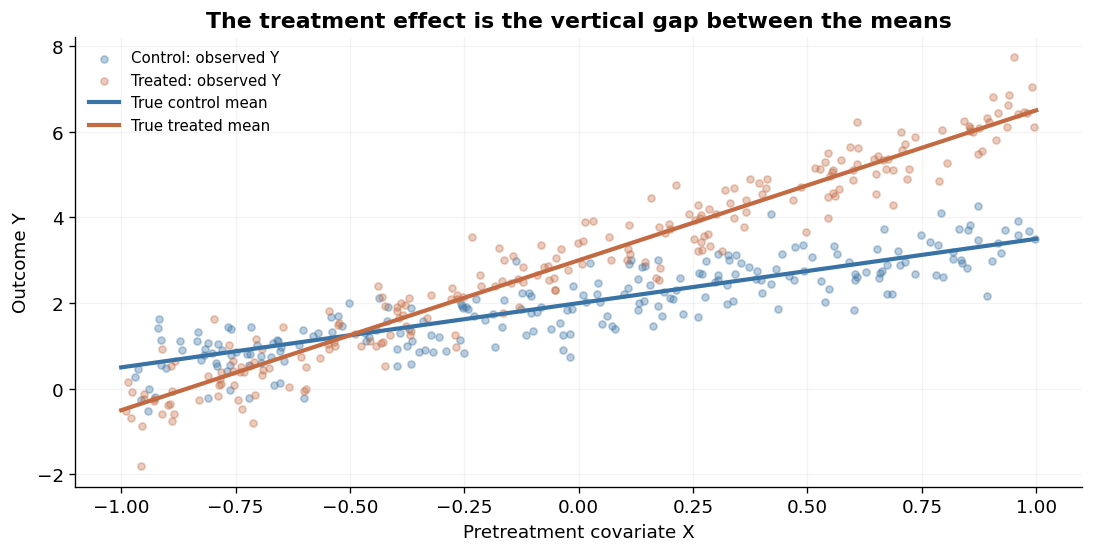

In [6]:
grid = pd.DataFrame({"X": np.linspace(-1.0, 1.0, 201)})
x_grid = grid["X"].to_numpy()

fig, ax = plt.subplots(layout="constrained")
for t, label, color in [(0, "Control", COLORS["control"]),
                        (1, "Treated", COLORS["treated"])]:
    group = train.loc[train["T"] == t]
    ax.scatter(group["X"], group["Y"], color=color, s=18,
               alpha=0.35, label=f"{label}: observed Y")
ax.plot(x_grid, true_mu0(x_grid), color=COLORS["control"], lw=2.5,
        label="True control mean")
ax.plot(x_grid, true_mu1(x_grid), color=COLORS["treated"], lw=2.5,
        label="True treated mean")
ax.set(xlabel="Pretreatment covariate X", ylabel="Outcome Y",
       title="The treatment effect is the vertical gap between the means")
ax.legend(fontsize=9)
plt.show()


## 6. Fit two TabPFN outcome models

I used a **T-learner**, just meaning that I fitted two outcome models:

| Model | Rows it gets | Features | Target | Quantity it estimates |
| :--- | :--- | :--- | :--- | :--- |
| Control model | Training rows with $T=0$ | $X$ | Observed $Y$ | $\mu_0(x)$ |
| Treated model | Training rows with $T=1$ | $X$ | Observed $Y$ | $\mu_1(x)$ |

Treatment determines which rows go into each model. It does not need to be an input feature within either group because it is constant there.

Then, for the **same value of $x$**, I calculate

$$\widehat\tau(x)=\widehat\mu_1(x)-\widehat\mu_0(x).$$

I'll request `output_type="mean"` explicitly. CATE is a difference of conditional means, so those are the predictions I need. This option is documented in the [regressor implementation](https://github.com/PriorLabs/TabPFN/blob/main/src/tabpfn/regressor.py).


One thing I want to be clear about before calling `.fit()`: TabPFN already has pretrained network weights. In this standard use, `.fit()` prepares our observed training data as context; we are not running a new gradient-descent training loop on this dataset.

During pretraining, PFNs learn across datasets generated from a prior over prediction problems. That is where the prior enters this approach. At prediction time, the trained network uses the supplied dataset to approximate posterior-predictive behavior. It is not explicitly trying a list of regression coefficients and printing a posterior for each one here. See the original [PFN paper](https://arxiv.org/abs/2112.10510) for that connection.

The little linear simulator above is our evaluation world. It does not replace TabPFN's pretraining prior, and we never give TabPFN the true coefficients.


In [8]:
def make_tabpfn(seed=SEED):
    options = {
        "device": DEVICE,
        "n_estimators": N_ESTIMATORS,
        "random_state": seed,
    }
    if MODEL_PATH is not None:
        options["model_path"] = MODEL_PATH
    return TabPFNRegressor.create_default_for_version(ModelVersion.V2, **options)


control_rows = train["T"] == 0
treated_rows = train["T"] == 1

control_model = make_tabpfn()
treated_model = make_tabpfn()

control_model.fit(train.loc[control_rows, FEATURES], train.loc[control_rows, "Y"])
treated_model.fit(train.loc[treated_rows, FEATURES], train.loc[treated_rows, "Y"])

print(f"Control context: {control_rows.sum()} observed outcomes")
print(f"Treated context: {treated_rows.sum()} observed outcomes")
print("Both models are ready.")


Control context: 226 observed outcomes
Treated context: 224 observed outcomes
Both models are ready.


`n_estimators=4` averages four TabPFN ensemble predictions within each outcome model. It is not the number of causal models, sampled treatment effects, or posterior coefficient draws. We still have two outcome models.

## 7. Do the subtraction for one value of X

Now I can return to $x=0.5$. I pass that same value to the control model and the treated model. Each one gives me an estimated conditional mean. Their difference is the estimated CATE at $0.5$.

We already worked out that the true answer is $2$. The values below come from the fitted models.


In [9]:
x_person = pd.DataFrame({"X": [0.5]})

mu0_person = float(control_model.predict(x_person, output_type="mean")[0])
mu1_person = float(treated_model.predict(x_person, output_type="mean")[0])
cate_person = mu1_person - mu0_person

display(pd.DataFrame({
    "Quantity at X = 0.5": ["Control mean", "Treated mean", "CATE"],
    "TabPFN estimate": [mu0_person, mu1_person, cate_person],
    "True value": [true_mu0(0.5), true_mu1(0.5), true_cate(0.5)],
}))
print(f"Estimated CATE: {mu1_person:.3f} - {mu0_person:.3f} = {cate_person:.3f}")


Estimated CATE: 4.675 - 2.743 = 1.933


,Quantity at X = 0.5,TabPFN estimate,True value
0,Control mean,2.743,2.75
1,Treated mean,4.675,4.75
2,CATE,1.933,2.00


The last row is an estimate of the **average effect among people with $X=0.5$**. A row representing one person does not turn this into that person's identified individual effect.

## 8. Repeat this across values of X

The calculation stays the same. I'll predict both means on a grid for the plot, and on the held-out covariates for evaluation. The grid is just a set of query values; its true outcomes are never used for fitting.


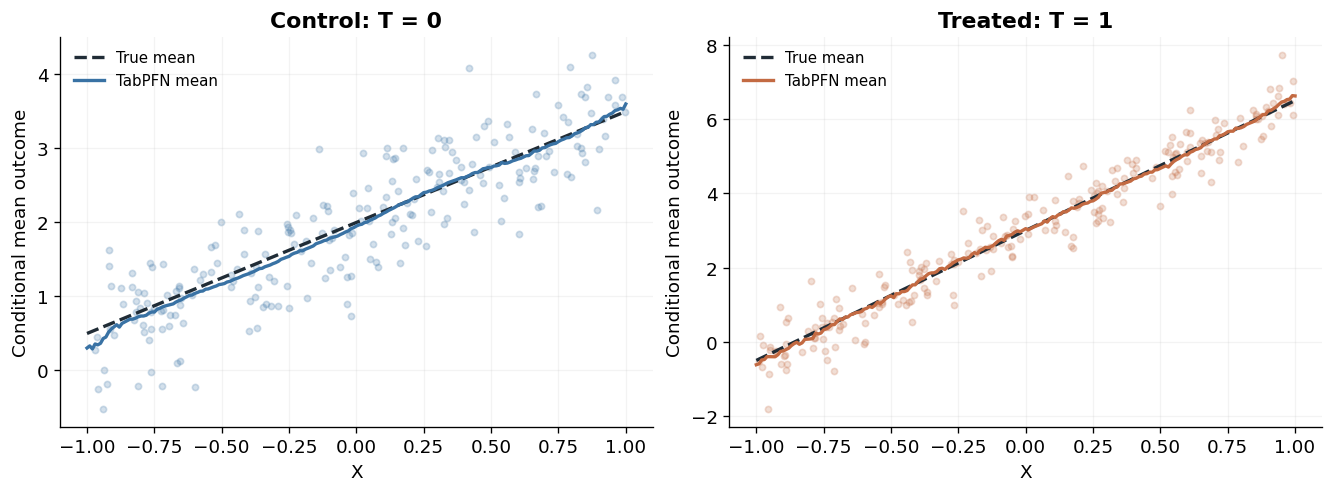

In [10]:
mu0_grid = control_model.predict(grid[FEATURES], output_type="mean")
mu1_grid = treated_model.predict(grid[FEATURES], output_type="mean")
cate_grid = mu1_grid - mu0_grid

mu0_test = control_model.predict(test[FEATURES], output_type="mean")
mu1_test = treated_model.predict(test[FEATURES], output_type="mean")
cate_test = mu1_test - mu0_test

assert cate_test.shape == truth_test.shape
assert np.isfinite(cate_test).all()
np.testing.assert_allclose(cate_test, mu1_test - mu0_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, t, estimated, true_mean, color in [
    (axes[0], 0, mu0_grid, true_mu0(x_grid), COLORS["control"]),
    (axes[1], 1, mu1_grid, true_mu1(x_grid), COLORS["treated"]),
]:
    group = train.loc[train["T"] == t]
    ax.scatter(group["X"], group["Y"], s=14, alpha=0.22, color=color)
    ax.plot(x_grid, true_mean, color=COLORS["truth"], ls="--", lw=2,
            label="True mean")
    ax.plot(x_grid, estimated, color=color, lw=2, label="TabPFN mean")
    ax.set(xlabel="X", ylabel="Conditional mean outcome",
           title="Control: T = 0" if t == 0 else "Treated: T = 1")
    ax.legend(fontsize=9)
plt.show()


## 9. Give linear regression the same task

Since I deliberately made the conditional means linear, I should include a correctly specified linear regression as a comparison:

$$Y=\beta_0+\beta_X X+\beta_T T+\beta_{TX}TX+\epsilon.$$

For this model, setting $T=1$ and $T=0$ and subtracting gives

$$\widehat\tau_{\mathrm{OLS}}(x)=\widehat\beta_T+\widehat\beta_{TX}x.$$

OLS gets the right functional form, although it still has to estimate the coefficients. TabPFN gets the observed data without being told that each conditional mean is a straight line. OLS has a real advantage in this example, and it may be more accurate.


In [11]:
def linear_design(x, t):
    x = np.asarray(x)
    t = np.broadcast_to(np.asarray(t), x.shape)
    return pd.DataFrame({"X": x, "T": t, "TX": t * x})


ols = LinearRegression()
ols.fit(linear_design(train["X"], train["T"]), train["Y"])

def ols_cate(x):
    return ols.coef_[1] + ols.coef_[2] * np.asarray(x)

ols_cate_grid = ols_cate(x_grid)
ols_cate_test = ols_cate(test["X"])

display(pd.DataFrame({
    "Coefficient": ["Intercept", "X", "T", "T × X"],
    "OLS estimate": [ols.intercept_, *ols.coef_],
    "True value": [2.0, 1.5, 1.0, 2.0],
}))

# Verify that the coefficient formula equals the two-prediction calculation.
np.testing.assert_allclose(
    ols_cate_test,
    ols.predict(linear_design(test["X"], 1))
    - ols.predict(linear_design(test["X"], 0)),
)


,Coefficient,OLS estimate,True value
0,Intercept,1.957,2.0
1,X,1.565,1.5
2,T,1.030,1.0
3,T × X,1.971,2.0


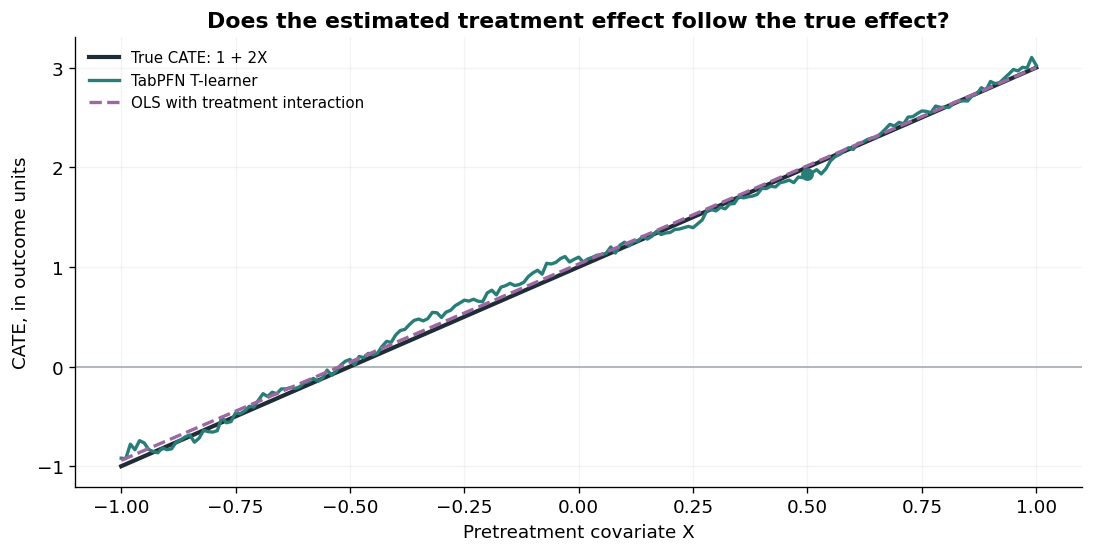

In [12]:
fig, ax = plt.subplots(layout="constrained")
ax.axhline(0, color="#a5abb0", lw=1)
ax.plot(x_grid, true_cate(x_grid), color=COLORS["truth"], lw=2.5,
        label="True CATE: 1 + 2X")
ax.plot(x_grid, cate_grid, color=COLORS["tabpfn"], lw=2,
        label="TabPFN T-learner")
ax.plot(x_grid, ols_cate_grid, color=COLORS["ols"], ls="--", lw=2,
        label="OLS with treatment interaction")
ax.scatter([0.5], [cate_person], color=COLORS["tabpfn"], s=45, zorder=4)
ax.set(xlabel="Pretreatment covariate X", ylabel="CATE, in outcome units",
       title="Does the estimated treatment effect follow the true effect?")
ax.legend(fontsize=9)
plt.show()


The true effect crosses zero at $X=-0.5$. Below that point, treatment lowers the expected outcome; above it, treatment raises it. The dot marks the TabPFN estimate we calculated at $X=0.5$.

TabPFN is allowed to produce a curved estimate even though the truth is linear. Any wiggles here are estimation error relative to the known straight line.

I'll quantify that with **CATE RMSE** on the held-out observations:

$$\operatorname{RMSE}_{\tau}=\sqrt{\frac{1}{n_{\mathrm{test}}}\sum_i[\widehat\tau(X_i)-\tau(X_i)]^2}.$$

I'll also report CATE MAE and observed-outcome RMSE. They answer different questions: one checks treatment-effect estimates against the simulated truth; the other checks predictions of the outcomes we actually observed. A good outcome score does not, by itself, establish good causal estimates.


In [13]:
def rmse(actual, predicted):
    return float(np.sqrt(np.mean((np.asarray(predicted) - np.asarray(actual)) ** 2)))


tabpfn_y_test = np.where(test["T"] == 1, mu1_test, mu0_test)
ols_y_test = ols.predict(linear_design(test["X"], test["T"]))

scores = pd.DataFrame([
    {"Model": name,
     "CATE RMSE": rmse(truth_test, tau_hat),
     "CATE MAE": float(np.mean(np.abs(tau_hat - truth_test))),
     "Observed Y RMSE": rmse(test["Y"], y_hat)}
    for name, tau_hat, y_hat in [
        ("TabPFN T-learner", cate_test, tabpfn_y_test),
        ("OLS with T × X", ols_cate_test, ols_y_test),
    ]
]).set_index("Model")
display(scores)

display(pd.DataFrame({
    "X": test["X"].to_numpy(),
    "True CATE": truth_test,
    "TabPFN CATE": cate_test,
    "OLS CATE": ols_cate_test,
}).sort_values("X").iloc[::max(1, len(test) // 8)])


,CATE RMSE,CATE MAE,Observed Y RMSE
Model,,,
TabPFN T-learner,0.076,0.062,0.501
OLS with T × X,0.034,0.029,0.499


,X,True CATE,TabPFN CATE,OLS CATE
75,-0.985,-0.971,-0.859,-0.912
30,-0.720,-0.441,-0.360,-0.390
92,-0.518,-0.037,0.021,0.009
111,-0.203,0.594,0.723,0.630
103,0.002,1.004,1.070,1.034
134,0.274,1.548,1.517,1.570
41,0.517,2.034,1.948,2.049
89,0.678,2.356,2.410,2.366
46,0.872,2.745,2.755,2.749


In the saved run, the CATE RMSE is **0.076 for TabPFN** and **0.034 for OLS**. Both recover the pattern, and OLS is more accurate here. That makes sense given how I generated the data: the conditional means are exactly linear, and OLS was given the matching specification. These are results from one simulated dataset, so I would repeat the experiment before making a broader comparison. If I change the seed or model settings, I should read the new results from the table above.

## 10. Average CATE to get an ATE estimate

For this population, $X\sim\operatorname{Uniform}(-1,1)$, so $\mathbb{E}[X]=0$. That gives

$$\operatorname{ATE}=\mathbb{E}_X[\tau(X)]=1+2\mathbb{E}[X]=1.$$

I can estimate the population ATE by averaging the estimated CATEs over a representative sample of covariates. Here I'll use the held-out sample:

$$\widehat{\operatorname{ATE}}=\frac{1}{n_{\mathrm{test}}}\sum_i\widehat\tau(X_i).$$

The average *true* CATE over these particular held-out covariates need not be exactly $1$. Their mean $X$ need not be exactly zero. I'll show both quantities so sampling variation in $X$ stays separate from error in estimating the CATE function.


In [14]:
display(pd.Series({
    "Population ATE (known)": 1.0,
    "Mean true CATE over held-out X": float(truth_test.mean()),
    "Mean TabPFN CATE over held-out X": float(cate_test.mean()),
    "Mean OLS CATE over held-out X": float(ols_cate_test.mean()),
}, name="Effect, in outcome units").to_frame())


,"Effect, in outcome units"
Population ATE (known),1.000
Mean true CATE over held-out X,1.046
Mean TabPFN CATE over held-out X,1.077
Mean OLS CATE over held-out X,1.076


## 11. Optional extension: let X affect treatment assignment

Now I'll keep the same potential-outcome equations but change treatment assignment to

$$P(T=1\mid X=x)=0.5+0.25x.$$

People with larger $X$ are more likely to receive treatment, and $X$ also affects their outcomes. The treated and control groups will therefore differ in their covariate distributions. A raw difference in their average outcomes mixes the treatment effect with those differences.

Conditioning on $X$ is enough in this simulation because assignment is independent of the potential-outcome errors once $X$ is fixed. Treatment probabilities range from $0.25$ to $0.75$, so overlap is maintained. The same T-learner calculation is still identified under these assumptions.

This section fits two additional models. It can take a little longer on a CPU.


In [15]:
obs_data, obs_oracle = simulate_data(seed=SEED + 1, observational=True)
obs_train_idx, obs_test_idx = train_test_split(
    obs_data.index.to_numpy(), test_size=0.25,
    random_state=SEED, stratify=obs_data["T"],
)
obs_train = obs_data.loc[obs_train_idx].copy()
obs_test = obs_data.loc[obs_test_idx].copy()
obs_truth_test = obs_oracle.loc[obs_test_idx, "cate_true"].to_numpy()

obs_control = make_tabpfn()
obs_treated = make_tabpfn()
obs_control.fit(obs_train.loc[obs_train["T"] == 0, FEATURES],
                obs_train.loc[obs_train["T"] == 0, "Y"])
obs_treated.fit(obs_train.loc[obs_train["T"] == 1, FEATURES],
                obs_train.loc[obs_train["T"] == 1, "Y"])

obs_mu0_test = obs_control.predict(obs_test[FEATURES], output_type="mean")
obs_mu1_test = obs_treated.predict(obs_test[FEATURES], output_type="mean")
obs_cate_test = obs_mu1_test - obs_mu0_test

naive_difference = (
    obs_train.loc[obs_train["T"] == 1, "Y"].mean()
    - obs_train.loc[obs_train["T"] == 0, "Y"].mean()
)

display(obs_train.groupby("T").agg(
    n=("Y", "size"), mean_X=("X", "mean"), mean_Y=("Y", "mean"),
).rename(index={0: "Control", 1: "Treated"}))

display(pd.Series({
    "Population ATE (known)": 1.0,
    "Mean true CATE over held-out X": float(obs_truth_test.mean()),
    "Raw outcome difference in training groups": float(naive_difference),
    "Mean adjusted TabPFN CATE over held-out X": float(obs_cate_test.mean()),
}, name="Effect / observed difference").to_frame())
print(f"Observational CATE RMSE: {rmse(obs_truth_test, obs_cate_test):.3f}")


Observational CATE RMSE: 0.082


,n,mean_X,mean_Y
T,,,
Control,235,-0.176,1.728
Treated,215,0.169,3.574


,Effect / observed difference
Population ATE (known),1.000
Mean true CATE over held-out X,1.022
Raw outcome difference in training groups,1.845
Mean adjusted TabPFN CATE over held-out X,1.016


Notice that the adjusted estimate predicts **both treatment conditions for the same held-out covariates**, then averages their differences. That is the adjustment. Subtracting predictions averaged over the treated group's $X$ values and the control group's different $X$ values would not do the same thing.

One simulated run can show how the calculation works. It cannot tell me how often an estimator succeeds. To study that, I would repeat the entire simulation and estimation procedure across seeds and summarize the errors.


## 12. A few things I want to try next

| Change | What I would look for |
| :--- | :--- |
| Change `SEED` | How much the estimates vary across independent datasets. |
| Increase `N` or `NOISE_SD` | How sample size and outcome noise affect CATE error. Keep CPU fits small. |
| Change `true_cate(x)` to `1 + 2*x**2` | How TabPFN handles a nonlinear effect. The OLS specification above would then need an additional $T X^2$ term to stay correctly specified. |
| Make the propensity closer to 0 or 1 | Where limited overlap makes conditional-effect estimation difficult. |
| Add an unobserved common cause of treatment and outcome | How estimates can fail when conditional exchangeability fails. |

After changing the data-generating functions or settings, rerun from the simulation onward. The written numerical examples describe the original setup; if I change the functional form, I also need to update its analytic truth and the coefficient table.

This notebook estimates **CATE point values**. It does not provide confidence intervals or a doubly robust estimator. TabPFN's outcome prediction intervals do not automatically give valid CATE confidence intervals, and subtracting their endpoints does not solve that problem.

For real data, I would need a defensible treatment definition, pretreatment adjustment variables, an identification argument, and a separate plan for uncertainty. Here, the simulation gives us those assumptions and the true CATE, which lets us see the estimation step clearly.


### Sources behind the setup

- Künzel et al., [*Meta-learners for Estimating Heterogeneous Treatment Effects using Machine Learning*](https://arxiv.org/abs/1706.03461): the causal setup and T-learner construction.
- Müller et al., [*Transformers Can Do Bayesian Inference*](https://arxiv.org/abs/2112.10510): the prior-data fitted network idea.
- Prior Labs, [TabPFN repository](https://github.com/PriorLabs/TabPFN), [regressor API implementation](https://github.com/PriorLabs/TabPFN/blob/main/src/tabpfn/regressor.py), and [v2 regression model](https://huggingface.co/Prior-Labs/TabPFN-v2-reg): installation, version selection, and prediction behavior.

The simulated data, coefficients, calculations, and figures are created for this notebook.
